# Import modules

In [1]:
import os
import sys
import joblib
import json
import numpy as np
import pandas as pd

# For over-sampling techniques
from imblearn.over_sampling import SMOTE, ADASYN
from collections import Counter

# Ensure the project root is in the system path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.Helper import (
    create_pipeline,
    load_and_split_data,
    preprocess_data,
    save_pipeline,
    predict_with_model,
    evaluate_model,
)

from src.XGBoost import train_xgboost_model, train_xgboost_model_with_optuna

c:\Users\PC\miniconda3\envs\vpbank\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Preparation

In [2]:
# 1. Load and split data T
data_path = os.path.join("..", "data", "train.csv")
train_data, test_data = load_and_split_data(data_path)

# 2. Create pipeline
pipeline = create_pipeline()

# 3. Fit pipeline on train data only
X_train, y_train, outlier_bounds, missing_fill_strategy = preprocess_data(
    train_data, pipeline, train=True
)

# Save the fitted pipeline (if needed)
save_pipeline(
    preprocessing_pipeline=pipeline,
    outlier_bounds=outlier_bounds,
    missing_fill_strategy=missing_fill_strategy,
)

# 4. Apply fitted pipeline and scaler to test data
X_test, y_test = preprocess_data(
    test_data,
    pipeline,
    missing_fill_strategy=missing_fill_strategy,
    outlier_bounds=outlier_bounds,
    train=False,
)

LOADING AND SPLITTING DATA


d:\Study\VPBank_Hackathon_25\src\Helper.py:102: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path)


Raw data loaded: (100000, 28)
After dropping personal info: (100000, 24)
Train data: (80000, 24)
Test data: (20000, 24)

PREPROCESSING DATA
Data after pipeline: (80000, 60)
Handling missing values with intelligent strategy...
  Monthly_Inhand_Salary: 12032 missing -> median (3191104166666666.0000) (skewed: 2.60)
  Num_of_Delayed_Payment: 5595 missing -> median (14.0000) (skewed: 14.21)
  Changed_Credit_Limit: 1691 missing -> median (902.0000) (skewed: 10.44)
  Num_Credit_Inquiries: 1549 missing -> median (60.0000) (skewed: 9.69)
  Credit_History_Age: 7240 missing -> mean (18.4345) (normal dist)
  Amount_invested_monthly: 3605 missing -> median (8131127094677352.0000) (skewed: 1.77)
  Monthly_Balance: 950 missing -> median (6580492431588418.0000) (skewed: 106.26)
Converting object columns to numeric codes...
Handling outliers...
  Age: 2210 outliers clipped
  Annual_Income: 3409 outliers clipped
  Monthly_Inhand_Salary: 5965 outliers clipped
  Num_Bank_Accounts: 1056 outliers clipped
  

# Over-sampling

In [3]:
# Check class distribution before oversampling
print("Original class distribution:")
print(Counter(y_train))
print(f"Class distribution percentages:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} ({count/len(y_train)*100:.2f}%)")

# Apply ADASYN oversampling
print("\nApplying ADASYN oversampling...")
# ADASYN with better parameters
adasyn = ADASYN(
    random_state=42,
    n_neighbors=5,  # Increased for better synthetic samples
    sampling_strategy="auto",  # Automatically balance all classes
)
X_train, y_train = adasyn.fit_resample(X_train, y_train)

print("Class distribution after ADASYN:")
print(Counter(y_train))
print(f"New training set size: {len(X_train)} samples")

# Show percentage after balancing
unique_after, counts_after = np.unique(y_train, return_counts=True)
for cls, count in zip(unique_after, counts_after):
    print(f"Class {cls}: {count} ({count/len(y_train)*100:.2f}%)")

Original class distribution:
Counter({2: 42539, 1: 23199, 0: 14262})
Class distribution percentages:
Class 0: 14262 (17.83%)
Class 1: 23199 (29.00%)
Class 2: 42539 (53.17%)

Applying ADASYN oversampling...
Class distribution after ADASYN:
Counter({0: 46129, 1: 44835, 2: 42539})
New training set size: 133503 samples
Class 0: 46129 (34.55%)
Class 1: 44835 (33.58%)
Class 2: 42539 (31.86%)


# XGBoost

## Find best parameters using Optuna

In [4]:
# best_model, best_params, _ = train_xgboost_model_with_optuna(X_train, y_train, n_trials=10)

# # Save best parameters and study results
# with open(os.path.join("..", "models", "best_params.json"), "w") as f:
#     json.dump(best_params, f)
    
# accuracy = evaluate_model(best_model, X_test, y_test)

# joblib.dump(best_model, os.path.join("..", "models", "xgboost.pkl"))

## Final Model

In [5]:
# Load test data
test_data = pd.read_csv(os.path.join("..", "data", "test.csv"))

# Load the trained model
model = joblib.load(os.path.join("..", "models", "xgboost.pkl"))

# Load the fitted pipeline
pipeline = joblib.load(os.path.join("..", "models", "pipeline.pkl"))
info = joblib.load(os.path.join("..", "models", "info.pkl"))
outlier_bounds = info["outlier_bounds"]
missing_fill_strategy = info["missing_fill_strategy"]

In [6]:
# Apply the same preprocessing to test data
X, _ = preprocess_data(
    test_data,
    pipeline,
    missing_fill_strategy=missing_fill_strategy,
    outlier_bounds=outlier_bounds,
    train=False,
)


PREPROCESSING DATA
Data after pipeline: (50000, 59)
Handling missing values with intelligent strategy...
  Name: 5015 missing -> 'unknown' (fallback)
  SSN: 2828 missing -> 'unknown' (fallback)
  Monthly_Inhand_Salary: 7498 missing -> mean (7472545779655046.0000) (fallback)
  Num_of_Delayed_Payment: 3498 missing -> mean (30.9104) (fallback)
  Changed_Credit_Limit: 1059 missing -> mean (593535481499067.1250) (fallback)
  Num_Credit_Inquiries: 1035 missing -> mean (300.8020) (fallback)
  Credit_History_Age: 4470 missing -> mean (18.9376) (fallback)
  Amount_invested_monthly: 2271 missing -> mean (12092411294240548.0000) (fallback)
  Monthly_Balance: 562 missing -> mean (40454725428432030662656.0000) (fallback)
Converting object columns to numeric codes...
  Converting ID to numeric codes
  Converting Customer_ID to numeric codes
  Converting Name to numeric codes
  Converting SSN to numeric codes
'Credit_Score' column not found. Using all columns as features.
Applying outlier clipping u

### Performance


MODEL EVALUATION
Test Accuracy: 0.8051

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.75      0.76      3566
           1       0.80      0.81      0.81      5799
           2       0.82      0.82      0.82     10635

    accuracy                           0.81     20000
   macro avg       0.79      0.79      0.79     20000
weighted avg       0.81      0.81      0.81     20000



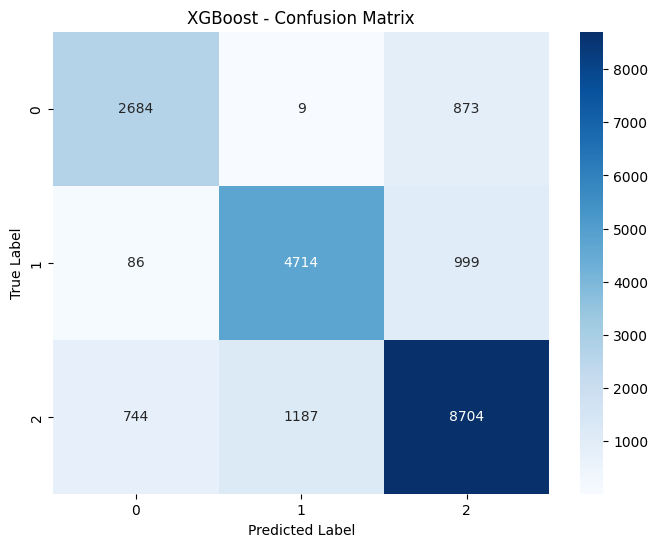

(0.8051,
 array([2, 1, 1, ..., 2, 0, 1], shape=(20000,)),
 array([[2.7725142e-03, 4.7139141e-01, 5.2583611e-01],
        [5.8190821e-04, 8.1873393e-01, 1.8068410e-01],
        [7.0383381e-03, 9.0682828e-01, 8.6133316e-02],
        ...,
        [3.5172109e-02, 2.1824108e-02, 9.4300377e-01],
        [7.4842405e-01, 2.6298512e-02, 2.2527742e-01],
        [7.0475001e-04, 9.0748894e-01, 9.1806300e-02]],
       shape=(20000, 3), dtype=float32))

In [7]:
evaluate_model(model, X_test=X_test, y_test=y_test)

### Predict

In [8]:
predict_with_model(
    model=model,
    X=X,
)


MAKING PREDICTIONS


(array([0, 0, 0, ..., 0, 0, 2], shape=(50000,)),
 array([[0.6843888 , 0.15031137, 0.16529982],
        [0.64446265, 0.12242218, 0.2331152 ],
        [0.677465  , 0.13846675, 0.18406829],
        ...,
        [0.5751373 , 0.16913974, 0.25572294],
        [0.54411936, 0.19557302, 0.26030758],
        [0.3548327 , 0.15029521, 0.49487206]],
       shape=(50000, 3), dtype=float32))